# 01 - Data and exploratory analysis

Download the weekly German load and Berlin temperature, look at the components and seasonality, and test for stationarity. Run top to bottom.

In [ ]:

%matplotlib inline
import sys
from pathlib import Path
for cand in [Path.cwd(), *Path.cwd().parents]:
    if (cand / 'src' / 'electricity_demand').exists():
        sys.path.insert(0, str(cand / 'src')); break
import warnings; warnings.filterwarnings('ignore')

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from electricity_demand import data, features, plotting as viz, config

In [ ]:
# Steps to do here :  1-3: download, clean, aggregate to weekly average load in GW.
weekly, hourly, n_gaps = data.build_weekly_load(save=True)
print(f'weekly points: {len(weekly)} | hourly gaps filled: {n_gaps}')
weekly.head()

weekly points: 301 | hourly gaps filled: 0


utc_timestamp
2015-01-04    47.233740
2015-01-11    56.191101
2015-01-18    57.672679
2015-01-25    58.613304
2015-02-01    58.734030
Freq: W-SUN, Name: load_gw, dtype: float64

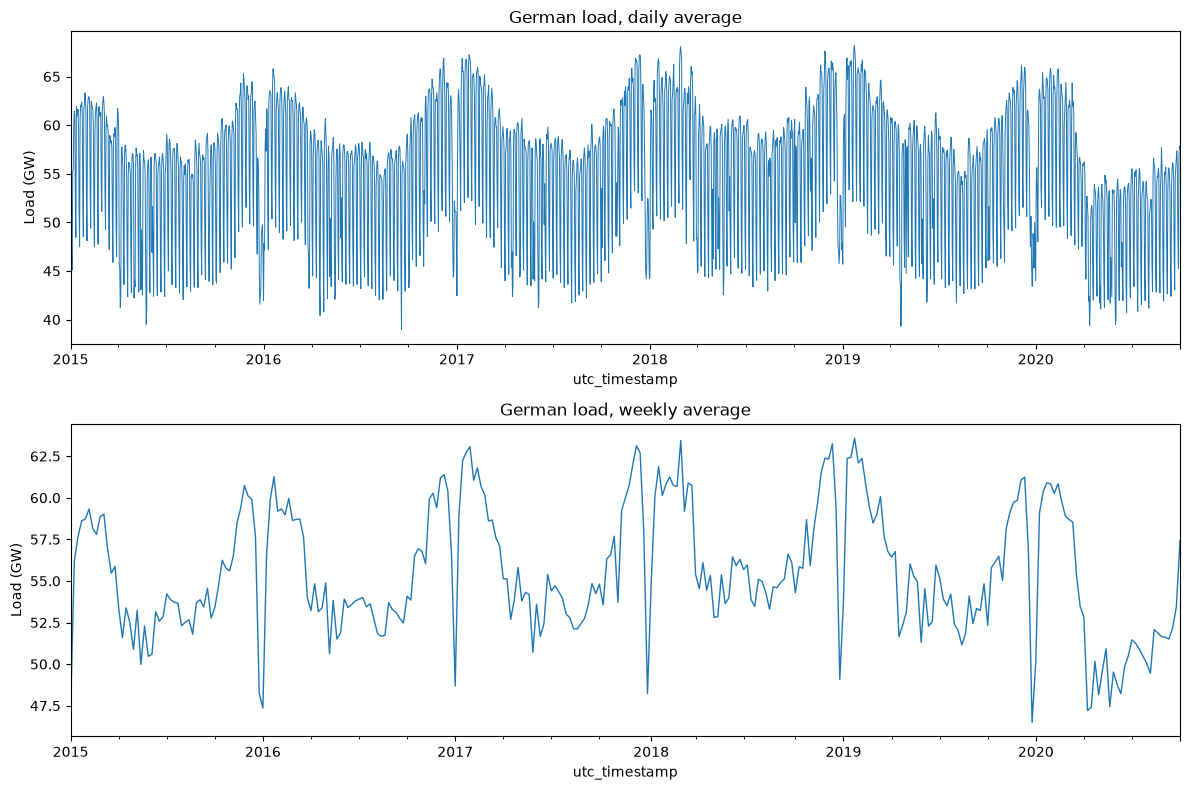

In [ ]:
# Daily and weekly plot.
daily_gw = hourly.resample('D').mean() / 1000.0
viz.series_overview(daily_gw, weekly); plt.show()

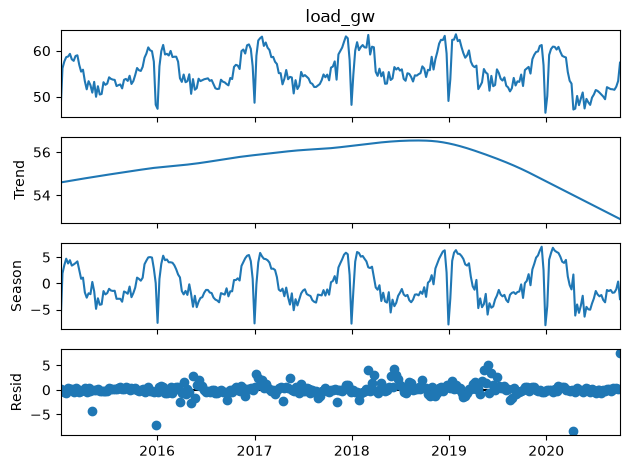

seasonal swing (std): 3.46 GW
remainder     (std): 1.27 GW


In [5]:
# Components: STL splits the weekly series into trend, seasonal and remainder.
stl = STL(weekly.dropna(), period=config.SEASON, robust=True).fit()
stl.plot(); plt.show()
print(f'seasonal swing (std): {stl.seasonal.std():.2f} GW')
print(f'remainder     (std): {stl.resid.std():.2f} GW')

In [6]:
# Stationarity: ADF (null = unit root) and KPSS (null = stationary).
def adf(s, name):
    stat, p, *_ = adfuller(s.dropna())
    print(f'ADF  | {name}: p={p:.4f} -> ' + ('stationary' if p<0.05 else 'non-stationary'))
def kp(s, name):
    stat, p, *_ = kpss(s.dropna(), regression='c', nlags='auto')
    print(f'KPSS | {name}: p={p:.4f} -> ' + ('stationary' if p>0.05 else 'non-stationary'))
adf(weekly, 'level'); kp(weekly, 'level')
adf(weekly.diff(config.SEASON), 'seasonal diff'); kp(weekly.diff(config.SEASON), 'seasonal diff')

ADF  | level: p=0.0012 -> stationary
KPSS | level: p=0.1000 -> stationary
ADF  | seasonal diff: p=0.0005 -> stationary
KPSS | seasonal diff: p=0.0100 -> non-stationary


C:\Users\HP\AppData\Local\Temp\ipykernel_11592\3803703422.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(s.dropna(), regression='c', nlags='auto')
C:\Users\HP\AppData\Local\Temp\ipykernel_11592\3803703422.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, *_ = kpss(s.dropna(), regression='c', nlags='auto')


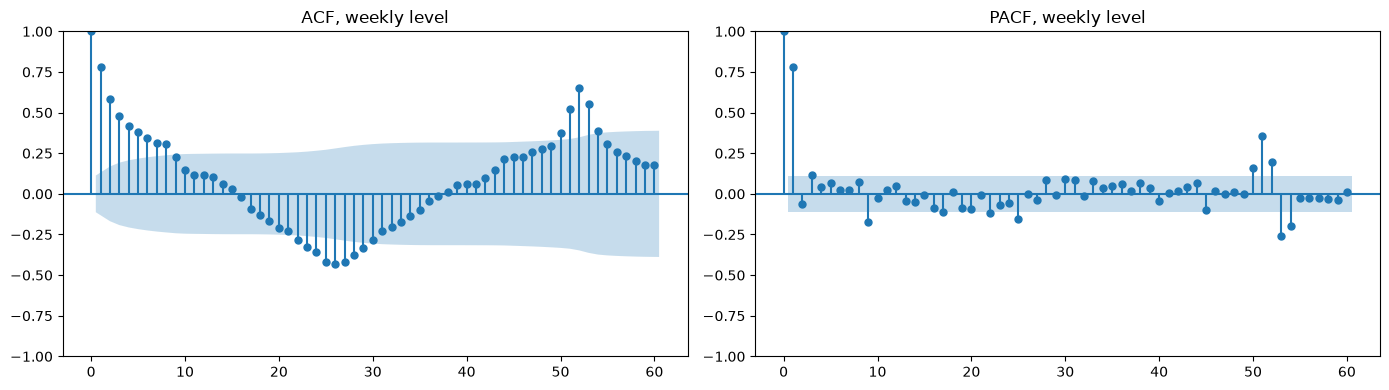

In [7]:
# ACF and PACF of the level.
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(weekly.dropna(), lags=60, ax=ax[0]); ax[0].set_title('ACF, weekly level')
plot_pacf(weekly.dropna(), lags=60, ax=ax[1], method='ywm'); ax[1].set_title('PACF, weekly level')
plt.tight_layout(); plt.show()

load vs temp_mean corr      : -0.637
load vs heating_degree corr : 0.694
weeks containing a holiday  : 48


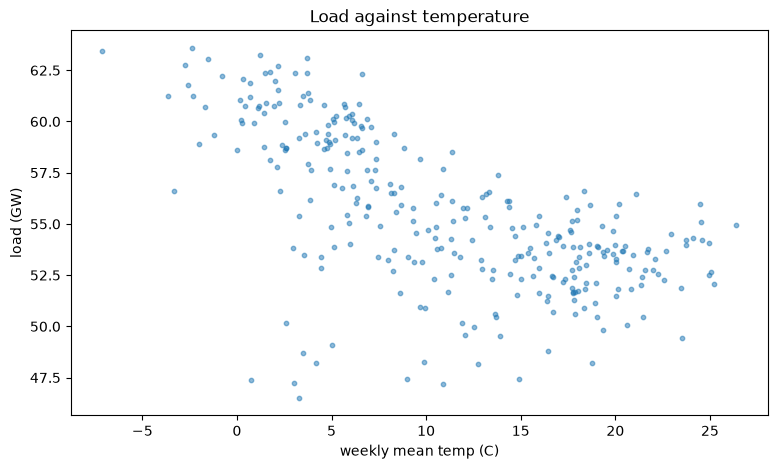

In [8]:
# Temperature and holidays: the external covariates.
temp = data.download_temperature(start=str(weekly.index.min().date()),
                                 end=str(weekly.index.max().date()))
tw = features.weekly_temperature_features(temp, weekly.index)
hol = features.holiday_features(weekly.index)
print('load vs temp_mean corr      :', round(weekly.corr(tw['temp_mean']), 3))
print('load vs heating_degree corr :', round(weekly.corr(tw['heating_degree_days']), 3))
print('weeks containing a holiday  :', int(hol['has_holiday'].sum()))
fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(tw['temp_mean'], weekly, s=10, alpha=0.5)
ax.set_xlabel('weekly mean temp (C)'); ax.set_ylabel('load (GW)')
ax.set_title('Load against temperature'); plt.show()